### What This Notebook Does
- Prepares raw fitness studio member data for machine learning and reporting
- Handles common data issues: inconsistent text fields, outliers, nulls
- Outputs a cleaned dataset ready for:
  - Predictive churn modeling
  - Member behavior insights
  - Studio-level KPIs and segmentation

In [47]:
import pandas as pd
import numpy as np
from datetime import datetime
import plotly.graph_objects as go
from plotly.subplots import make_subplots

### Load Dataset

This step imports the raw fitness studio data from `fitness_studio_data.csv`. The file is a unified export that simulates real-world studio member behavior, including referral source, age, engagement, churn status, and more.

A quick preview helps verify structure and detect any immediate formatting issues.

In [4]:
df_members = pd.read_csv("./data/fitness_studio_data.csv")
df_members.head()

,member_id,engagement_score,home_studio_region,gender,age,membership_tenure_months,avg_weekly_classes_last_6_months,num_unique_class_types_attended,auto_renew_enabled,last_attended_30_days_flag,monthly_membership_cost,referral_source,is_churned,studio_name,studio_id
0,M0001,53,Region_0,Non-binary,42.751540,13,2.730769,4,1,1,229,Online Ad,0,Cherry Knolls,STUDIO_012
1,M0002,63,Region_8,Female,62.732375,45,2.115385,4,1,1,129,Employer Program,0,Broomfield,STUDIO_001
2,M0003,77,Region_2,Non-binary,22.286105,52,3.115385,4,1,1,169,Online Ad,0,Hilltop Village,STUDIO_006
3,M0004,78,Region_0,Female,34.206708,53,3.192308,4,1,1,169,Online Ad,0,Hilltop Village,STUDIO_006
4,M0005,21,Region_6,Female,53.776865,30,0.653846,4,1,0,169,Online Ad,1,Castle Rock,STUDIO_015


In [5]:
df_members.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2081 entries, 0 to 2080
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   member_id                         2081 non-null   object 
 1   engagement_score                  2081 non-null   int64  
 2   home_studio_region                2081 non-null   object 
 3   gender                            2081 non-null   object 
 4   age                               2076 non-null   float64
 5   membership_tenure_months          2081 non-null   int64  
 6   avg_weekly_classes_last_6_months  2081 non-null   float64
 7   num_unique_class_types_attended   2081 non-null   int64  
 8   auto_renew_enabled                2081 non-null   int64  
 9   last_attended_30_days_flag        2081 non-null   int64  
 10  monthly_membership_cost           2081 non-null   int64  
 11  referral_source                   2081 non-null   object 
 12  is_chu

#### Studio Location Join
To enable geospatial analysis during EDA, studio address fields from studios.csv were combined into a single address_full field and merged with the member-level dataset via studio_id. This enriched field will support mapping and location-based churn insights (e.g., urban vs suburban churn patterns or market clustering).

In [7]:
# add studio address from studios.csv
df_studios = pd.read_csv("./data/studios.csv")

# create a full address field in df_studios
df_studios['address_full'] = (
    df_studios['address'].astype(str).str.strip() + ", " +
    df_studios['city'].astype(str).str.strip() + ", " +
    df_studios['state'].astype(str).str.strip() + " " +
    df_studios['zip'].astype(str).str.strip()
)
df_studios.head(5)

,studio_id,studio_name,address,city,state,zip,class_capacity,address_full
0,STUDIO_001,Broomfield,1285 E 1ST AVENUE,Broomfield,CO,80020,33,"1285 E 1ST AVENUE, Broomfield, CO 80020"
1,STUDIO_004,Uptown Denver,450 E. 17TH AVE,Denver,CO,80203,39,"450 E. 17TH AVE, Denver, CO 80203"
2,STUDIO_005,Denver Highlands,3300 W 32ND AVENUE,Denver,CO,80211,39,"3300 W 32ND AVENUE, Denver, CO 80211"
3,STUDIO_006,Hilltop Village,4243 E 136TH AVE,Thornton,CO,80602,33,"4243 E 136TH AVE, Thornton, CO 80602"
4,STUDIO_008,Applewood Village,3244 YOUNGFIELD ST,Wheat Ridge,CO,80033,39,"3244 YOUNGFIELD ST, Wheat Ridge, CO 80033"


In [8]:
# check for duplicates in df_studios
studio_dupes = df_studios['studio_id'].duplicated().sum()
print(f"Duplicate studio_id rows in studios.csv: {studio_dupes}")

Duplicate studio_id rows in studios.csv: 0


In [9]:
# confirm row counts stay stable after the join
pre_merge_count = df_members.shape[0]

df_members = df_members.merge(
    df_studios[['studio_id', 'address_full']],
    on = 'studio_id',
    how = 'left'
)

post_merge_count = df_members.shape[0]

print(f"Rows before merge: {pre_merge_count}")
print(f"Rows after merge: {post_merge_count}")

Rows before merge: 2081
Rows after merge: 2081


In [10]:
# check for failed joins
missing_addresses = df_members['address_full'].isna().sum()
print(f"Members with no address_full after join: {missing_addresses}")

Members with no address_full after join: 0


### Standardize Referral Sources

The `referral_source` field contains inconsistent labels due to typos, formatting differences, and free-text entry. This is common in real-world CRM or POS systems where intake is manual or varies by location.

Standardizing these values ensures reliable aggregation and analysis — especially when measuring marketing channel performance, acquisition trends, or churn by referral source.

In [12]:
print(df_members['referral_source'].sort_values().unique())

['Com. Event' 'Community Event' 'CommunityEvent' 'Empl Program'
 'Employer Prgrm' 'Employer Program' 'Frend' 'Friend' 'Online Ad'
 'OnlineAd' 'Onlne Ad' 'Other' 'Othr' 'Partner Ship' 'Partnership'
 'Partnrship' 'Soc. Media' 'Social Media' 'SocialMedia' 'WALK-IN'
 'Walk in' 'Walk-in' 'friend' 'frnd' 'onlinead' 'othr' 'soc media'
 'walkin']


In [13]:
# Standardize referral source values
referral_clean_map = {
    "OnlineAd": "Online Ad",
    "onlinead": "Online Ad",
    "Onlne Ad": "Online Ad",
    "Employer Prgrm": "Employer Program",
    "Empl Program": "Employer Program",
    "CommunityEvent": "Community Event",
    "Com. Event": "Community Event",
    "soc media": "Social Media",
    "SocialMedia": "Social Media",
    "Soc. Media": "Social Media",
    "Walk in": "Walk-in",
    "walkin": "Walk-in",
    "WALK-IN": "Walk-in",
    "Frend": "Friend",
    "friend": "Friend",
    "frnd": "Friend",
    "Othr": "Other",
    "othr": "Other",
    "Partner Ship": "Partnership",
    "Partnrship": "Partnership"
}

df_members['referral_source'] = df_members['referral_source'].replace(referral_clean_map)

In [14]:
print(df_members['referral_source'].sort_values().unique())

['Community Event' 'Employer Program' 'Friend' 'Online Ad' 'Other'
 'Partnership' 'Social Media' 'Walk-in']


### Handle Invalid Age Entries

The `age` field may include outliers due to data entry errors — for example, unrealistically low or high values. While fitness studios like Orangetheory typically require members to be at least 14, and very few exceed age 90, there is no universally enforced policy.

In a production environment, the analytics team would work with Legal and Operations to define official thresholds. For now, ages below 10 or above 100 are considered invalid and replaced with the average of valid ages.

In [16]:
print("Age value summary:")
print(df_members['age'].describe())

print("\nUnrealistic age values:")
print(df_members[(df_members['age'] < 10) | (df_members['age'] > 100)]['age'].value_counts().sort_index())

Age value summary:
count    2076.000000
mean       41.754183
std        14.035159
min        18.986995
25%        30.251882
50%        41.583847
75%        52.930185
max       209.772000
Name: age, dtype: float64

Unrealistic age values:
age
115.384    1
187.275    1
209.772    1
Name: count, dtype: int64


In [17]:
df_age = df_members['age'].copy()
df_age.describe()

count    2076.000000
mean       41.754183
std        14.035159
min        18.986995
25%        30.251882
50%        41.583847
75%        52.930185
max       209.772000
Name: age, dtype: float64

In [18]:
# flag age outliers (e.g., over 100 or under 10)
invalid_age = (df_members['age'] > 100) | (df_members['age'] < 10)

# calculate mean age of valid members
mean_valid_age = df_members.loc[~invalid_age, 'age'].mean().round(1)

# replace invalid ages with the mean of valid ages
df_members.loc[invalid_age, 'age'] = mean_valid_age

# replace nulls (NaNs) with the same mean
df_members['age'] = df_members['age'].fillna(mean_valid_age)

In [19]:
df_age_clean = df_members['age'].copy()
df_age_clean.describe()

count    2081.000000
mean       41.567542
std        13.042928
min        18.986995
25%        30.261465
50%        41.600000
75%        52.854209
max        63.956194
Name: age, dtype: float64

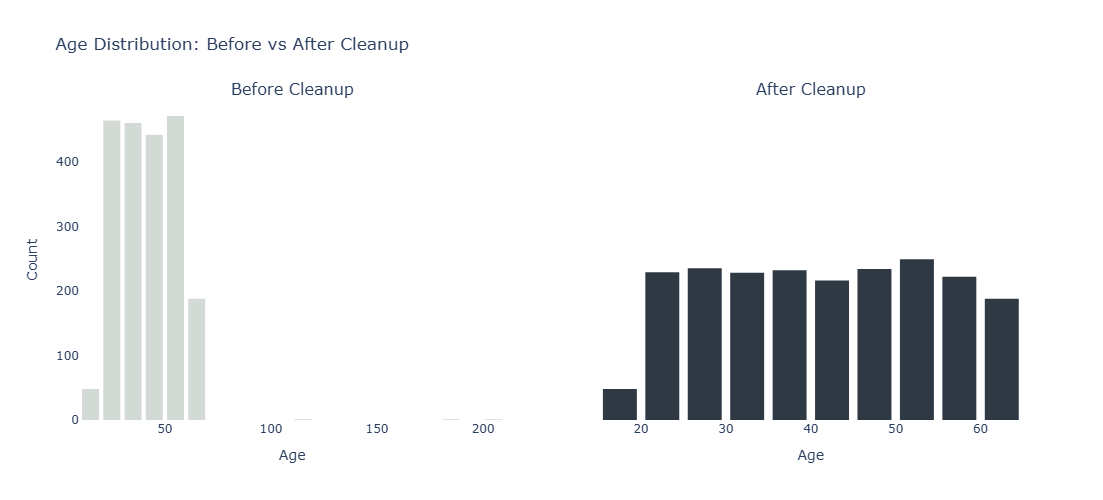

In [51]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Before Cleanup", "After Cleanup"),
    shared_yaxes=True
)

fig.add_trace(go.Histogram(
    x=df_age,
    nbinsx=20,
    name='Before Cleanup',
    marker_color='#D3D9D4'
), row=1, col=1)

fig.add_trace(go.Histogram(
    x=df_age_clean,
    nbinsx=20,
    name='After Cleanup',
    marker_color='#2E3944'
), row=1, col=2)

fig.update_layout(
    title_text='Age Distribution: Before vs After Cleanup',
    plot_bgcolor='white',
    paper_bgcolor='white',
    bargap=0.2,
    width=1000,
    height=500,
    showlegend=False
)

fig.update_xaxes(title_text='Age', row=1, col=1)
fig.update_xaxes(title_text='Age', row=1, col=2)
fig.update_yaxes(title_text='Count', row=1, col=1)

fig.show()

### Format Binary Flags for Modeling

Binary fields such as `auto_renew_enabled` and `last_attended_30_days_flag` are explicitly cast to integers. This step ensures they are interpreted correctly as numeric flags in downstream tools such as scikit-learn, Power BI, and Looker.

In [22]:
# ensure binary flags are consistent 0/1 values (not strings or booleans)
flag_cols = ['auto_renew_enabled', 'last_attended_30_days_flag', 'is_churned']
df_members[flag_cols] = df_members[flag_cols].astype(int)

### Cast Categorical Fields to String

Text-based fields such as `gender`, `referral_source`, and `studio_name` are explicitly converted to string. This prevents misclassification during import and ensures reliable groupings, encodings, and aggregations across analysis and modeling steps.

In [24]:
# convert categorical columns to string type for consistency
cat_cols = ['gender', 'referral_source', 'home_studio_region', 'studio_name', 'studio_id']
df_members[cat_cols] = df_members[cat_cols].astype(str)

### Final Data Check and Export

Before exporting the cleaned dataset, it's important to confirm there are no missing values in critical fields and that the column formats align with modeling requirements.

This step finalizes the transformation pipeline and prepares the file for EDA and churn prediction modeling.

In [26]:
# Optional: Check for nulls
print("Missing values per column:")
print(df_members.isnull().sum())

# Save cleaned dataset
df_members.to_csv("./data/fitness_studio_data_clean.csv", index=False)
print('fitness_studio_data_clean.csv has been saved')

Missing values per column:
member_id                           0
engagement_score                    0
home_studio_region                  0
gender                              0
age                                 0
membership_tenure_months            0
avg_weekly_classes_last_6_months    0
num_unique_class_types_attended     0
auto_renew_enabled                  0
last_attended_30_days_flag          0
monthly_membership_cost             0
referral_source                     0
is_churned                          0
studio_name                         0
studio_id                           0
address_full                        0
dtype: int64
fitness_studio_data_clean.csv has been saved
